# Visual Question Answering for Chart Images -- Ahmad Agah

Binary (Yes/No) VQA on the FigureQA dataset using a **Dual-Scale CNN Encoder** (parallel branches extracting spatial features at 14×14 and 7×7 resolutions, fused via element-wise addition) + **Custom Transformer Encoder** (6 layers, self-attention implemented from scratch) + **2-Layer Stacked Cross-Attention Fusion** (image tokens attend to question tokens across 2 sequential cross-attention layers) + MLP Classifier.
```
                              ┌─ Conv3 (14x14) ─> Pool(7x7) ─> Project ─┐
Image (224x224) ──> CNN ──────┤                                          ├─ Add+Norm ──┐
                              └─ Conv4 ( 7x7 ) ─────────────> Project ─┘              │
                                                                                       ├─ 2x Cross-Attention ──> MLP ──> Yes/No
Question tokens ──> 6-layer Transformer ──> (batch, 32, 512) ─────────────────────┘
```

21.9M parameters. **Everything from scratch** — no pretrained weights, no PyTorch built-in attention modules, no pretrained vision backbones.

### Hardware & Training Environment

Trained on **Google Colab** with an **NVIDIA A100-SXM4-40GB** GPU. At ~3.2 GFLOPs per sample (forward) and batch size 1024, each epoch processes 1,037 batches in roughly **25–30 minutes**. The full 10-epoch run completed in approximately **4–5 hours**. Checkpoints were saved after every epoch so training can pick up where it left off after Colab session timeouts.

| Setting | Value |
|---|---|
| **GPU** | NVIDIA A100-SXM4-40GB (Google Colab) |
| **Precision** | FP32 |
| **Batch Size** | 1024 (~10 GB of 40 GB VRAM utilized) |
| **Training Time** | ~4–5 hours (10 epochs × ~27 min/epoch) |
| **Dataset** | FigureQA — 1.3M QA pairs, split by image to prevent leakage |

---
## Section 1: Setup
Mount Google Drive, imports, paths, device detection, seed.

In [ ]:
import os
import io
import math
import glob
import random
import pickle
from collections import Counter

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

# Mount Google Drive
try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    pass

# Paths -- all absolute, no os.chdir()
PROJECT_DIR = '/content/drive/MyDrive/dlwin26-project/vqa-project'
OUTPUT_DIR = f'{PROJECT_DIR}/output'
CHECKPOINT_DIR = f'{OUTPUT_DIR}/checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
    torch.backends.cudnn.benchmark = True

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

Mounted at /content/drive
Device: cuda
GPU: NVIDIA A100-SXM4-40GB
VRAM: 42.4 GB


---
## Section 2: Configuration
All hyperparameters in one place.

In [ ]:
# Data
IMAGE_SIZE = 224       # FigureQA images are 640x480; 224 preserves chart details while matching standard CNN input
MAX_SEQ_LENGTH = 32    # longest FigureQA question is ~20 words; 32 gives padding room without wasting memory
VOCAB_SIZE = 200       # FigureQA has exactly 128 unique words (templated); 200 gives buffer for edge cases
TRAIN_IMAGES = 80000   # 80K of 100K images for training (~1.06M QA pairs)
VAL_IMAGES = 10000     # 10K images for validation (~133K QA pairs)
TEST_IMAGES = 10000    # 10K images for test (~133K QA pairs)

# Model
EMBED_DIM = 512        # shared across all components; 8 heads × 64 dims each
CNN_DIM = 1024         # widened from 512 in v1; narrow CNN was the bottleneck for color discrimination
NUM_HEADS = 8          # 512 / 8 = 64 dims per head; good balance of capacity per head
NUM_LAYERS = 6         # FigureQA questions reference 2 data series by color name; 6 layers lets the model relate them
FF_DIM = 1024          # 2× embed_dim; standard transformer FFN expansion
DROPOUT = 0.15         # 0.1 was too low (overfitting by epoch 6 in v1); 0.2 hurt convergence; 0.15 is the sweet spot
NUM_ANSWERS = 2        # binary: Yes / No

# Training
BATCH_SIZE = 1024      # fills ~28-30GB on A100 40GB VRAM
LEARNING_RATE = 3e-4   # Karpathy constant; stable default for AdamW with 20M+ param models
NUM_EPOCHS = 10        # full training run; each epoch ~1.06M samples
WARMUP_EPOCHS = 1      # linear warmup for 1 epoch before cosine decay
GRAD_CLIP = 1.0        # cross-attention between CNN and Transformer outputs can spike early in training
LABEL_SMOOTHING = 0.1  # softens Yes/No targets to [0.9, 0.1]; helps when FigureQA answers are near the decision boundary

---
## Section 3: Data Loading

Loads FigureQA from HuggingFace, builds vocabulary, creates PyTorch DataLoaders.

FigureQA contains 100K synthetic chart images (bar, line, pie, dot-line, area) with **1.3M** Yes/No questions across **15 templated question types**: min/max identification (*"Is the navy blue bar the minimum?"*), pairwise comparisons (*"Is X greater than Y?"*), median, smoothness/roughness, line intersections, and area under curve.

I split by **image** (80K/10K/10K) to prevent data leakage (same chart in train and test), then flatten all QA pairs within each split.

### Image Transforms
Training images get light augmentation (random flip, color jitter) to reduce overfitting. Validation/test images are only resized and normalized.

In [ ]:
MEAN = [0.485, 0.456, 0.406]  # ImageNet mean
STD = [0.229, 0.224, 0.225]   # ImageNet std

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(0.3),                  # FigureQA questions reference elements by color name, not position, so flipping is safe
    transforms.ColorJitter(brightness=0.1, contrast=0.1),  # light jitter; too much would distort chart colors
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])

### Vocabulary
Word-to-index mapping. `<PAD>` (index 0) fills short sequences, `<UNK>` (index 1) replaces unknown words.

In [ ]:
class Vocabulary:
    """Word-to-index mapping for question tokenization."""

    def __init__(self, max_size=5000):
        self.word2idx = {'<PAD>': 0, '<UNK>': 1}
        self.idx2word = {0: '<PAD>', 1: '<UNK>'}
        self.max_size = max_size

    def build(self, sentences):
        """Count word frequencies and keep the top max_size words."""
        counter = Counter()
        for sentence in sentences:
            counter.update(sentence.lower().split())

        for word, _ in counter.most_common(self.max_size - 2):
            idx = len(self.word2idx)
            self.word2idx[word] = idx
            self.idx2word[idx] = word

        print(f'Vocabulary: {len(self.word2idx)} words')

    def encode(self, sentence, max_length):
        """Convert sentence to padded list of token indices."""
        tokens = sentence.lower().split()
        indices = [self.word2idx.get(w, 1) for w in tokens[:max_length]]
        indices += [0] * (max_length - len(indices))
        return indices

    def __len__(self):
        return len(self.word2idx)

### FigureQA Dataset
PyTorch Dataset that returns `(image_tensor, question_tensor, answer_tensor)` per sample.

In [ ]:
class FigureQADataset(Dataset):
    """Wraps flattened FigureQA data into a PyTorch Dataset."""

    def __init__(self, images, questions, answers, vocab, transform, max_seq_length):
        self.images = images
        self.questions = questions
        self.answers = answers
        self.vocab = vocab
        self.transform = transform
        self.max_seq_length = max_seq_length

    def __len__(self):
        return len(self.questions)

    def __getitem__(self, idx):
        """Return (image_tensor, question_tensor, answer_tensor) for one QA pair."""
        img = self.images[idx]
        if isinstance(img, dict):
            image = Image.open(io.BytesIO(img['bytes'])).convert('RGB')
        else:
            image = img.convert('RGB')
        image = self.transform(image)

        question = self.vocab.encode(self.questions[idx], self.max_seq_length)
        question = torch.tensor(question, dtype=torch.long)

        answer = torch.tensor(self.answers[idx], dtype=torch.long)

        return image, question, answer

### Data Loading Functions
Load FigureQA from HuggingFace, split by image (not QA pair) to prevent data leakage, flatten QA pairs, and create DataLoaders.

In [ ]:
def load_figureqa(cache_dir, train_images, val_images, test_images):
    """Load FigureQA, split by IMAGE (not QA pair), then flatten QA pairs per split."""
    from datasets import load_dataset

    print('Loading FigureQA from HuggingFace...')
    raw = load_dataset('vikhyatk/figureqa', cache_dir=cache_dir, split='train')
    num_images = len(raw)
    print(f'Loaded {num_images:,} images')

    # Shuffle image indices and split
    indices = list(range(num_images))
    random.shuffle(indices)

    needed = train_images + val_images + test_images
    assert needed <= num_images, f'Need {needed} images but only {num_images} available'

    split_map = {
        'train': indices[:train_images],
        'val': indices[train_images:train_images + val_images],
        'test': indices[train_images + val_images:train_images + val_images + test_images],
    }

    # Flatten QA pairs within each split
    splits = {}
    for name, img_indices in split_map.items():
        images, questions, answers = [], [], []
        for i in tqdm(img_indices, desc=f'Processing {name}'):
            row = raw[i]
            img = row['image']
            for qa in row['qa']:
                images.append(img)
                questions.append(qa['question'])
                answers.append(1 if qa['answer'].strip().lower().startswith('yes') else 0)

        splits[name] = {
            'images': images,
            'questions': questions,
            'answers': answers,
        }
        yes_count = sum(answers)
        no_count = len(answers) - yes_count
        print(f'  {name}: {len(images):,} QA pairs from {len(img_indices):,} images '
              f'(Yes: {yes_count:,}, No: {no_count:,})')

    total_qa = sum(len(s['questions']) for s in splits.values())
    print(f'Total QA pairs: {total_qa:,}')
    return splits


def create_dataloaders(splits, vocab, batch_size, max_seq_length):
    """Create train/val/test DataLoaders from split data."""
    loaders = {}
    for name, transform in [('train', train_transform), ('val', val_transform), ('test', val_transform)]:
        ds = FigureQADataset(
            splits[name]['images'],
            splits[name]['questions'],
            splits[name]['answers'],
            vocab, transform, max_seq_length
        )
        loaders[name] = DataLoader(
            ds,
            batch_size=batch_size,
            shuffle=(name == 'train'),
            num_workers=2,           # 2 workers avoids the Colab multiprocessing cleanup errors
            pin_memory=True,
            persistent_workers=True  # keep workers alive between epochs
        )

    for name in ['train', 'val', 'test']:
        print(f'{name.capitalize()} batches: {len(loaders[name]):,}')

    return loaders['train'], loaders['val'], loaders['test']

### Load Data (skip-if-done)
If `data_splits.pkl` exists on Drive, load it (~30s). Otherwise download from HuggingFace (~5min) and save the pickle.

In [ ]:
DATA_SPLITS_PATH = f'{OUTPUT_DIR}/data_splits.pkl'

if os.path.exists(DATA_SPLITS_PATH):
    print('Loading cached data splits from Drive...')
    with open(DATA_SPLITS_PATH, 'rb') as f:
        saved = pickle.load(f)
    splits = saved['splits']
    vocab = saved['vocab']
    print(f'Loaded: train={len(splits["train"]["questions"]):,}, '
          f'val={len(splits["val"]["questions"]):,}, '
          f'test={len(splits["test"]["questions"]):,}')
    print(f'Vocabulary: {len(vocab)} words')
else:
    # Download to local Colab disk (not Drive) -- parquet files are ~2.2GB, no need to persist
    splits = load_figureqa(
        cache_dir='/content/data/figureqa',
        train_images=TRAIN_IMAGES,
        val_images=VAL_IMAGES,
        test_images=TEST_IMAGES,
    )

    vocab = Vocabulary(max_size=VOCAB_SIZE)
    vocab.build(splits['train']['questions'])

    # Save to Drive so next run skips the download
    print('Saving data splits to Drive...')
    with open(DATA_SPLITS_PATH, 'wb') as f:
        pickle.dump({'splits': splits, 'vocab': vocab}, f)
    print('Saved.')

Loading cached data splits from Drive...
Loaded: train=1,061,144, val=132,697, test=133,527
Vocabulary: 128 words


### Create DataLoaders

In [ ]:
train_loader, val_loader, test_loader = create_dataloaders(
    splits, vocab, BATCH_SIZE, MAX_SEQ_LENGTH
)

Train batches: 1,037
Val batches: 130
Test batches: 131


---
## Section 4: Model Architecture

CNN Encoder + Transformer Encoder (from scratch) + Cross-Attention Fusion + Classifier.

### Part 1: Multi-Scale CNN Encoder
Extracts features at **two scales** and combines them. Mid-level features (conv3, 14x14) capture colors and edges critical for questions like *"Is the navy blue bar..."*. High-level features (conv4, 7x7) capture semantic structure. Both are pooled to 7x7, projected to embed_dim, and added — inspired by PReFIL's multi-scale approach.

| Layer | Channels | Spatial | What it learns |
|-------|----------|---------|----------------|
| Conv1 (7x7, stride 2) | 3 -> 64 | 224 -> 112 | Edges, basic colors |
| MaxPool (3x3, stride 2) | 64 | 112 -> 56 | Downsample |
| Conv2 (3x3, stride 2) | 64 -> 256 | 56 -> 28 | Color patches, line segments |
| **Conv3** (3x3, stride 2) | 256 -> 512 | 28 -> **14** | **Mid-level: colors, chart elements** |
| **Conv4** (3x3, stride 2) | 512 -> 1024 | 14 -> **7** | **High-level: spatial relationships** |
| AdaptivePool | 512 | 14 -> 7 | Align mid-level to 7x7 grid |
| Project (mid) | 512 -> 512 | -- | Mid features to embed_dim |
| Project (high) | 1024 -> 512 | -- | High features to embed_dim |
| **Output** | **512** | **7x7 = 49** | **mid + high, LayerNormed** |

In [ ]:
class ConvBlock(nn.Module):
    """Conv -> BatchNorm -> ReLU. Stride 2 halves spatial dimensions."""

    def __init__(self, in_channels, out_channels, kernel_size=3, stride=2, padding=1):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding)
        self.bn = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        """Apply conv -> batchnorm -> relu."""
        return self.relu(self.bn(self.conv(x)))


class CNNEncoder(nn.Module):
    """Multi-scale CNN: combines mid-level (colors/edges) and high-level (semantic) features."""

    def __init__(self, cnn_dim=CNN_DIM, embed_dim=EMBED_DIM):
        super().__init__()
        self.cnn_dim = cnn_dim

        self.conv1 = ConvBlock(3, 64, kernel_size=7, stride=2, padding=3)   # 224 -> 112
        self.pool = nn.MaxPool2d(3, stride=2, padding=1)                    # 112 -> 56
        self.conv2 = ConvBlock(64, 256)                                     # 56 -> 28
        self.conv3 = ConvBlock(256, 512)                                    # 28 -> 14 (mid-level)
        self.conv4 = ConvBlock(512, cnn_dim)                                # 14 -> 7  (high-level)

        # Multi-scale: pool mid-level to 7x7 to match high-level spatial dims
        self.adaptive_pool = nn.AdaptiveAvgPool2d(7)

        # Separate projections for each scale
        self.project_mid = nn.Linear(512, embed_dim)
        self.project_high = nn.Linear(cnn_dim, embed_dim)
        self.norm = nn.LayerNorm(embed_dim)

    def forward(self, x):
        """Extract multi-scale features and return (batch, 49, embed_dim)."""
        x = self.conv1(x)
        x = self.pool(x)
        x = self.conv2(x)
        mid = self.conv3(x)       # (batch, 512, 14, 14) -- colors, chart elements
        high = self.conv4(mid)    # (batch, cnn_dim, 7, 7) -- spatial relationships

        # Pool mid-level to 7x7 to match high-level
        mid = self.adaptive_pool(mid)  # (batch, 512, 7, 7)

        batch = high.shape[0]
        mid = mid.view(batch, 512, 49).permute(0, 2, 1)              # (batch, 49, 512)
        high = high.view(batch, self.cnn_dim, 49).permute(0, 2, 1)   # (batch, 49, cnn_dim)

        mid = self.project_mid(mid)      # (batch, 49, embed_dim)
        high = self.project_high(high)   # (batch, 49, embed_dim)

        return self.norm(mid + high)     # (batch, 49, embed_dim)

### Part 2: Transformer Primitives
Scaled dot-product attention, multi-head attention, positional encoding, and feed-forward network. All from scratch.

In [ ]:
def scaled_dot_product_attention(query, key, value, mask=None):
    """Compute scaled dot-product attention: softmax(QK^T / sqrt(d_k)) V."""
    d_k = query.size(-1)
    scores = torch.matmul(query, key.transpose(-2, -1)) / math.sqrt(d_k)  # (batch, heads, seq_q, seq_k)

    if mask is not None:
        scores = scores.masked_fill(mask == 0, float('-inf'))  # mask padding to -inf so they get 0 weight after softmax

    weights = F.softmax(scores, dim=-1)
    output = torch.matmul(weights, value)  # (batch, heads, seq_q, d_k)
    return output, weights


class MultiHeadAttention(nn.Module):
    """Multi-head attention from scratch. No nn.MultiheadAttention.
    Splits embed_dim into num_heads parallel attention heads, each with d_k = embed_dim // num_heads."""

    def __init__(self, embed_dim, num_heads):
        super().__init__()
        assert embed_dim % num_heads == 0

        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.d_k = embed_dim // num_heads

        self.W_q = nn.Linear(embed_dim, embed_dim)
        self.W_k = nn.Linear(embed_dim, embed_dim)
        self.W_v = nn.Linear(embed_dim, embed_dim)
        self.W_o = nn.Linear(embed_dim, embed_dim)

    def forward(self, query, key, value, mask=None):
        """Project inputs, split into heads, attend, merge heads back."""
        batch_size = query.size(0)

        # Project and reshape: (batch, seq, embed) -> (batch, heads, seq, d_k)
        Q = self.W_q(query).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        K = self.W_k(key).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        V = self.W_v(value).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)

        attn_output, attn_weights = scaled_dot_product_attention(Q, K, V, mask)

        # Merge heads: (batch, heads, seq, d_k) -> (batch, seq, embed)
        attn_output = attn_output.transpose(1, 2).contiguous().view(batch_size, -1, self.embed_dim)
        output = self.W_o(attn_output)  # final linear projection
        return output, attn_weights


class PositionalEncoding(nn.Module):
    """Sinusoidal positional encoding from 'Attention Is All You Need'.
    Adds fixed position signal so the model knows token order (embeddings alone are position-agnostic)."""

    def __init__(self, embed_dim, max_len=512):
        super().__init__()

        pe = torch.zeros(max_len, embed_dim)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, embed_dim, 2).float() * (-math.log(10000.0) / embed_dim)
        )

        pe[:, 0::2] = torch.sin(position * div_term)  # even dims get sin
        pe[:, 1::2] = torch.cos(position * div_term)  # odd dims get cos
        pe = pe.unsqueeze(0)  # (1, max_len, embed_dim) for broadcasting over batch
        self.register_buffer('pe', pe)

    def forward(self, x):
        """Add positional encoding to input embeddings."""
        return x + self.pe[:, :x.size(1)]


class FeedForward(nn.Module):
    """Position-wise FFN: Linear -> ReLU -> Dropout -> Linear.
    Expands to ff_dim (2x embed_dim) then projects back — adds non-linearity between attention layers."""

    def __init__(self, embed_dim, ff_dim, dropout=0.1):
        super().__init__()
        self.linear1 = nn.Linear(embed_dim, ff_dim)
        self.linear2 = nn.Linear(ff_dim, embed_dim)
        self.dropout = nn.Dropout(dropout)
        self.relu = nn.ReLU()

    def forward(self, x):
        """Apply expand -> ReLU -> dropout -> project."""
        return self.linear2(self.dropout(self.relu(self.linear1(x))))

### Part 3: Transformer Encoder
Stacks 6 encoder blocks: self-attention -> add & norm -> FFN -> add & norm. Padding mask zeroes out `<PAD>` tokens.

In [ ]:
class TransformerEncoderBlock(nn.Module):
    """One encoder block: Self-Attention -> Add & Norm -> FFN -> Add & Norm.
"""

    def __init__(self, embed_dim, num_heads, ff_dim, dropout=0.1):
        super().__init__()
        self.attention = MultiHeadAttention(embed_dim, num_heads)
        self.ff = FeedForward(embed_dim, ff_dim, dropout)
        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        """Apply self-attention + FFN with residual connections."""
        attn_out, attn_weights = self.attention(x, x, x, mask)  # self-attention: Q=K=V=x
        x = self.norm1(x + self.dropout1(attn_out))

        ff_out = self.ff(x)
        x = self.norm2(x + self.dropout2(ff_out))

        return x, attn_weights


class TransformerEncoder(nn.Module):
    """Full encoder: Token indices -> Embedding -> Positional Encoding -> N x EncoderBlock.
    Returns encoded features and attention weights from all layers."""

    def __init__(self, vocab_size, embed_dim, num_heads, num_layers, ff_dim,
                 max_seq_length, dropout=0.1):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)  # PAD token (idx 0) maps to zeros
        self.pos_encoding = PositionalEncoding(embed_dim, max_seq_length)
        self.dropout = nn.Dropout(dropout)

        self.layers = nn.ModuleList([
            TransformerEncoderBlock(embed_dim, num_heads, ff_dim, dropout)
            for _ in range(num_layers)
        ])

    def forward(self, x):
        """Embed tokens, add positions, run through encoder blocks."""
        # Padding mask: (batch, 1, 1, seq) — broadcast over heads and query positions
        # Prevents attention from attending to PAD tokens
        mask = (x != 0).unsqueeze(1).unsqueeze(2)

        x = self.embedding(x)
        x = self.pos_encoding(x)
        x = self.dropout(x)

        attn_weights_all = []
        for layer in self.layers:
            x, attn_weights = layer(x, mask)
            attn_weights_all.append(attn_weights)

        return x, attn_weights_all

### Part 4: Stacked Cross-Attention Fusion
Text features (queries) attend to image features (keys/values) through **2 stacked layers**. The first layer identifies relevant image regions; the second refines the reasoning. For *"Is navy blue greater than crimson?"*, layer 1 locates both colors, layer 2 compares their values.

In [ ]:
class CrossAttention(nn.Module):
    """Text queries attend to image keys/values. No mask needed — all 49 spatial positions are valid."""

    def __init__(self, embed_dim, num_heads):
        super().__init__()
        assert embed_dim % num_heads == 0

        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.d_k = embed_dim // num_heads

        self.W_q = nn.Linear(embed_dim, embed_dim)
        self.W_k = nn.Linear(embed_dim, embed_dim)
        self.W_v = nn.Linear(embed_dim, embed_dim)
        self.W_o = nn.Linear(embed_dim, embed_dim)

    def forward(self, query, key, value):
        """Attend from text queries to image key/value pairs."""
        batch_size = query.size(0)

        # Project and split heads: (batch, seq, embed) -> (batch, heads, seq, d_k)
        Q = self.W_q(query).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        K = self.W_k(key).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        V = self.W_v(value).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)

        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)
        weights = F.softmax(scores, dim=-1)
        attn_output = torch.matmul(weights, V)

        # Merge heads back: (batch, heads, seq, d_k) -> (batch, seq, embed)
        attn_output = attn_output.transpose(1, 2).contiguous().view(batch_size, -1, self.embed_dim)
        output = self.W_o(attn_output)

        return output, weights


class FusionModule(nn.Module):
    """Stacked cross-attention: text attends to image through N layers, then mean-pool."""

    def __init__(self, embed_dim, num_heads, num_layers=2, dropout=0.1):
        super().__init__()
        self.layers = nn.ModuleList([
            nn.ModuleDict({
                'cross_attn': CrossAttention(embed_dim, num_heads),
                'norm': nn.LayerNorm(embed_dim),
                'dropout': nn.Dropout(dropout),
            })
            for _ in range(num_layers)
        ])

    def forward(self, text_features, image_features):
        """Fuse text and image through stacked cross-attention, return pooled output."""
        x = text_features
        attn_weights = None
        for layer in self.layers:
            residual = x
            fused, attn_weights = layer['cross_attn'](
                query=x, key=image_features, value=image_features
            )
            x = layer['norm'](residual + layer['dropout'](fused))

        output = x.mean(dim=1)  # mean-pool over sequence length -> (batch, embed_dim)
        return output, attn_weights

### Part 5: VQA Model
Full pipeline: images and questions go in, Yes/No logits come out. Uses an MLP classifier (2 layers) instead of a single linear layer for non-linear decision boundaries.

In [ ]:
class VQAModel(nn.Module):
    """Full VQA: Multi-Scale CNN + Transformer + Stacked Cross-Attention + MLP Classifier."""

    def __init__(self, vocab_size, embed_dim, num_heads, num_layers, ff_dim,
                 max_seq_length, cnn_dim, num_answers, dropout=0.1):
        super().__init__()

        self.cnn = CNNEncoder(cnn_dim=cnn_dim, embed_dim=embed_dim)
        self.transformer = TransformerEncoder(
            vocab_size, embed_dim, num_heads, num_layers,
            ff_dim, max_seq_length, dropout
        )
        self.fusion = FusionModule(embed_dim, num_heads, num_layers=2, dropout=dropout)
        self.classifier = nn.Sequential(
            nn.Linear(embed_dim, embed_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(embed_dim, num_answers),
        )

    def forward(self, images, questions):
        """Run full VQA pipeline: image + question -> Yes/No logits."""
        image_features = self.cnn(images)
        text_features, _ = self.transformer(questions)
        fused, cross_attn = self.fusion(text_features, image_features)
        logits = self.classifier(fused)
        return logits, cross_attn


# Instantiate
model = VQAModel(
    vocab_size=len(vocab),
    embed_dim=EMBED_DIM,
    num_heads=NUM_HEADS,
    num_layers=NUM_LAYERS,
    ff_dim=FF_DIM,
    max_seq_length=MAX_SEQ_LENGTH,
    cnn_dim=CNN_DIM,
    num_answers=NUM_ANSWERS,
    dropout=DROPOUT,
).to(device)

# Shape verification with dummy data
_images = torch.randn(2, 3, 224, 224).to(device)
_questions = torch.randint(0, len(vocab), (2, 32)).to(device)
_logits, _cross_attn = model(_images, _questions)

print(f'Image input:       {_images.shape}')          # (2, 3, 224, 224)
print(f'Question input:    {_questions.shape}')        # (2, 32)
print(f'Logits output:     {_logits.shape}')           # (2, 2)
print(f'Cross-attn shape:  {_cross_attn.shape}')       # (2, 8, 32, 49)
print()

# Parameter count
cnn_params = sum(p.numel() for p in model.cnn.parameters())
transformer_params = sum(p.numel() for p in model.transformer.parameters())
fusion_params = sum(p.numel() for p in model.fusion.parameters())
classifier_params = sum(p.numel() for p in model.classifier.parameters())
total_params = sum(p.numel() for p in model.parameters())

print(f'CNN encoder:       {cnn_params:,}')
print(f'Transformer:       {transformer_params:,}')
print(f'Fusion:            {fusion_params:,}')
print(f'Classifier:        {classifier_params:,}')
print(f'Total parameters:  {total_params:,}')

del _images, _questions, _logits, _cross_attn

### Parameter Distribution Analysis

| Component | Parameters | Share |
|-----------|-----------|-------|
| CNN Encoder | 6.8M | 31% |
| Transformer | 12.7M | 58% |
| Fusion | 2.1M | 10% |
| Classifier | 0.26M | 1% |
| **Total** | **21.9M** | **100%** |

The Transformer dominates at 58% of total parameters — 6 self-attention layers with 512-dim embeddings and 4 projection matrices each (Q, K, V, O) accumulate parameters quickly, whereas the CNN uses only 4 convolutional blocks. The fusion module adds 2.1M (two cross-attention layers), and the MLP classifier is just 0.26M.

The 21.9M total is reasonable for 1.06M training samples (~20:1 sample-to-parameter ratio), which kept overfitting mild (train-val gap stayed under 1% through most of training).

---
## Section 5: Training

Training loop with checkpoint resume. Saves after every epoch to Google Drive.

### Checkpoint Utilities
Save/load model checkpoints and find the latest one for resume.

In [ ]:
def save_checkpoint(model, optimizer, epoch, train_loss, val_loss, val_acc, filename):
    """Save model + optimizer state to CHECKPOINT_DIR."""
    path = os.path.join(CHECKPOINT_DIR, filename)
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'train_loss': train_loss,
        'val_loss': val_loss,
        'val_acc': val_acc,
    }, path)


def load_checkpoint(filename, model, optimizer=None):
    """Load checkpoint and restore model (and optionally optimizer) state."""
    path = os.path.join(CHECKPOINT_DIR, filename)
    ckpt = torch.load(path, map_location=device, weights_only=False)
    model.load_state_dict(ckpt['model_state_dict'])
    if optimizer:
        optimizer.load_state_dict(ckpt['optimizer_state_dict'])
    return ckpt


def find_latest_checkpoint():
    """Find most recent checkpoint_epoch_N.pth, or None."""
    ckpts = glob.glob(os.path.join(CHECKPOINT_DIR, 'checkpoint_epoch_*.pth'))
    if not ckpts:
        return None
    latest = max(ckpts, key=lambda p: int(os.path.basename(p).split('_')[-1].split('.')[0]))
    return os.path.basename(latest)

### Training and Validation Functions

In [ ]:
CHECKPOINT_EVERY = 250  # save checkpoint every 250 batches (~15 min on A100)


def train_one_epoch(model, loader, criterion, optimizer, scheduler, epoch, best_val_loss):
    """Train for one epoch with mid-epoch checkpointing, return average loss and accuracy."""
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    pbar = tqdm(loader, desc='Training', leave=False)
    for batch_idx, (images, questions, answers) in enumerate(pbar, 1):
        images = images.to(device)
        questions = questions.to(device)
        answers = answers.to(device)

        optimizer.zero_grad()
        logits, _ = model(images, questions)
        loss = criterion(logits, answers)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item() * answers.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == answers).sum().item()
        total += answers.size(0)

        pbar.set_postfix(loss=f'{total_loss/total:.4f}', acc=f'{correct/total:.4f}')

        # Mid-epoch checkpoint every CHECKPOINT_EVERY batches
        if batch_idx % CHECKPOINT_EVERY == 0:
            avg_loss = total_loss / total
            save_checkpoint(
                model, optimizer, epoch, avg_loss, best_val_loss, 0,
                f'checkpoint_epoch_{epoch + 1}_batch_{batch_idx}.pth'
            )

    return total_loss / total, correct / total


def validate(model, loader, criterion):
    """Validate model, return average loss and accuracy."""
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, questions, answers in tqdm(loader, desc='Validating', leave=False):
            images = images.to(device)
            questions = questions.to(device)
            answers = answers.to(device)

            logits, _ = model(images, questions)
            loss = criterion(logits, answers)

            total_loss += loss.item() * answers.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == answers).sum().item()
            total += answers.size(0)

    return total_loss / total, correct / total

### Training Loop
Saves a checkpoint after every epoch and saves the best model (lowest val loss). Uses cosine annealing LR with linear warmup. Saves `training_history.pkl` with per-epoch metrics.

In [ ]:
def get_scheduler(optimizer, num_epochs, warmup_epochs, steps_per_epoch):
    """Cosine annealing with linear warmup (stepped per batch)."""
    total_steps = num_epochs * steps_per_epoch
    warmup_steps = warmup_epochs * steps_per_epoch

    def lr_lambda(step):
        """Return LR multiplier: linear warmup then cosine decay."""
        if step < warmup_steps:
            return step / max(warmup_steps, 1)  # linear warmup
        progress = (step - warmup_steps) / max(total_steps - warmup_steps, 1)
        return 0.5 * (1 + math.cos(math.pi * progress))  # cosine decay

    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler,
                num_epochs, start_epoch=0, best_val_loss=float('inf')):
    """Full training loop with checkpointing after every epoch."""
    history = []

    # Load existing history if resuming
    history_path = f'{OUTPUT_DIR}/training_history.pkl'
    if start_epoch > 0 and os.path.exists(history_path):
        with open(history_path, 'rb') as f:
            history = pickle.load(f)

    for epoch in range(start_epoch, num_epochs):
        lr = optimizer.param_groups[0]['lr']
        print(f'\nEpoch {epoch + 1}/{num_epochs} (lr: {lr:.6f})')
        print('-' * 50)

        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, scheduler,
            epoch, best_val_loss
        )
        val_loss, val_acc = validate(model, val_loader, criterion)

        print(f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}')
        print(f'Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}')

        history.append({
            'epoch': epoch + 1,
            'train_loss': train_loss,
            'train_acc': train_acc,
            'val_loss': val_loss,
            'val_acc': val_acc,
            'lr': lr,
        })

        # End-of-epoch checkpoint (clean name)
        save_checkpoint(
            model, optimizer, epoch, train_loss, val_loss, val_acc,
            f'checkpoint_epoch_{epoch + 1}.pth'
        )

        # Save best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            save_checkpoint(
                model, optimizer, epoch, train_loss, val_loss, val_acc,
                'best_model.pth'
            )
            print(f'>>> New best model saved (val_loss: {val_loss:.4f})')

        # Save history after every epoch
        with open(history_path, 'wb') as f:
            pickle.dump(history, f)

        # Clean up mid-epoch checkpoints for this epoch (keep only end-of-epoch)
        for mid_ckpt in glob.glob(os.path.join(CHECKPOINT_DIR, f'checkpoint_epoch_{epoch + 1}_batch_*.pth')):
            os.remove(mid_ckpt)

    print('\nTraining complete!')
    return best_val_loss

### Run Training (skip-if-done)
3-way logic:
1. `best_model.pth` + `training_history.pkl` exist -> skip training, load best model
2. `checkpoint_epoch_N.pth` exists -> resume from epoch N+1
3. Nothing exists -> train from scratch

In [ ]:
criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)
scheduler = get_scheduler(optimizer, NUM_EPOCHS, WARMUP_EPOCHS, len(train_loader))

best_model_path = os.path.join(CHECKPOINT_DIR, 'best_model.pth')
history_path = f'{OUTPUT_DIR}/training_history.pkl'

if os.path.exists(best_model_path) and os.path.exists(history_path):
    # Training already complete -- just load the best model
    print('Training already complete. Loading best model...')
    ckpt = load_checkpoint('best_model.pth', model)
    print(f'Loaded from epoch {ckpt["epoch"] + 1} (val_acc: {ckpt["val_acc"]:.4f})')
else:
    # Check for partial training to resume
    start_epoch = 0
    best_val_loss = float('inf')

    latest = find_latest_checkpoint()
    if latest:
        print(f'Resuming from {latest}')
        ckpt = load_checkpoint(latest, model, optimizer)
        start_epoch = ckpt['epoch'] + 1
        best_val_loss = ckpt['val_loss']
        # Advance scheduler to correct step position
        steps_done = start_epoch * len(train_loader)
        for _ in range(steps_done):
            scheduler.step()
        print(f'Starting at epoch {start_epoch + 1}, best val_loss: {best_val_loss:.4f}')
    else:
        print('Starting training from scratch')
        print(f'Model: {sum(p.numel() for p in model.parameters()):,} parameters')
        print(f'Train batches/epoch: {len(train_loader):,}')

    train_model(
        model, train_loader, val_loader, criterion, optimizer, scheduler,
        NUM_EPOCHS, start_epoch, best_val_loss
    )

    # Load best model for evaluation
    load_checkpoint('best_model.pth', model)
    print('Loaded best model for evaluation.')

Starting training from scratch
Model: 21,898,370 parameters
Train batches/epoch: 1,037

Epoch 1/10 (lr: 0.000000)
--------------------------------------------------


Training:   0%|          | 0/1037 [00:00<?, ?it/s]

Validating:   0%|          | 0/130 [00:00<?, ?it/s]

Train Loss: 0.6896 | Train Acc: 0.5222
Val Loss:   0.6843 | Val Acc:   0.5360
>>> New best model saved (val_loss: 0.6843)

Epoch 2/10 (lr: 0.000300)
--------------------------------------------------


Training:   0%|          | 0/1037 [00:00<?, ?it/s]

...

Validating:   0%|          | 0/130 [00:00<?, ?it/s]

Train Loss: 0.6646 | Train Acc: 0.5690
Val Loss:   0.6690 | Val Acc:   0.5650
>>> New best model saved (val_loss: 0.6690)

Epoch 10/10 (lr: 0.000009)
--------------------------------------------------


Training:   0%|          | 0/1037 [00:00<?, ?it/s]

Validating:   0%|          | 0/130 [00:00<?, ?it/s]

Train Loss: 0.6637 | Train Acc: 0.5699
Val Loss:   0.6690 | Val Acc:   0.5652
>>> New best model saved (val_loss: 0.6690)

Training complete!
Loaded best model for evaluation.


### Training Analysis

Key observations from the training logs:

1. **Warmup epoch** — Epoch 1 shows LR `0.000000` due to the linear warmup starting from zero. The model still learned slightly (52.2% train accuracy) from small LR increments within the epoch.
2. **Steady but slow improvement** — Loss decreased every epoch (0.6896 → 0.6637) and accuracy climbed from 52.2% → 57.0% on train, but the per-epoch gains diminished throughout training.
3. **Validation plateau at epoch 7-8** — Validation accuracy plateaued around 56.5%, and the train-val gap widened slightly in later epochs, a sign of mild overfitting.
4. **Marginal late-stage gains** — Best val_loss improved by only 0.0001 between epochs 9-10 (0.6691 → 0.6690) — essentially flat.
5. **Bottleneck analysis** — FigureQA questions depend heavily on distinguishing similar colors (e.g., *"Is navy blue greater than crimson?"*). A CNN trained from scratch on 80K chart images lacks the visual priors needed for fine-grained color discrimination, which limits the ceiling on this task.

---
## Section 6: Evaluation

Test set evaluation with accuracy, per-class breakdown, and confusion matrix.

### Evaluation Functions

In [ ]:
def evaluate(model, loader):
    """Run model on a dataset, return predictions and true labels."""
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, questions, answers in tqdm(loader, desc='Evaluating', leave=False):
            images = images.to(device)
            questions = questions.to(device)

            logits, _ = model(images, questions)
            preds = logits.argmax(dim=1)

            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(answers.tolist())

    return all_preds, all_labels


def compute_metrics(preds, labels):
    """Compute and print accuracy metrics and confusion matrix."""
    correct = sum(p == l for p, l in zip(preds, labels))
    total = len(preds)
    accuracy = correct / total

    yes_correct = sum(1 for p, l in zip(preds, labels) if l == 1 and p == 1)
    yes_total = sum(1 for l in labels if l == 1)
    no_correct = sum(1 for p, l in zip(preds, labels) if l == 0 and p == 0)
    no_total = sum(1 for l in labels if l == 0)

    print(f'Overall Accuracy: {accuracy:.4f} ({correct}/{total})')
    if yes_total > 0:
        print(f'Yes Accuracy:     {yes_correct / yes_total:.4f} ({yes_correct}/{yes_total})')
    if no_total > 0:
        print(f'No Accuracy:      {no_correct / no_total:.4f} ({no_correct}/{no_total})')

    tp = sum(1 for p, l in zip(preds, labels) if p == 1 and l == 1)
    fp = sum(1 for p, l in zip(preds, labels) if p == 1 and l == 0)
    fn = sum(1 for p, l in zip(preds, labels) if p == 0 and l == 1)
    tn = sum(1 for p, l in zip(preds, labels) if p == 0 and l == 0)

    print()
    print('Confusion Matrix:')
    print(f'              Pred No  Pred Yes')
    print(f'Actual No     {tn:<8} {fp}')
    print(f'Actual Yes    {fn:<8} {tp}')

    return accuracy

### Run Evaluation on Test Set

In [ ]:
print('Evaluating on test set...')
preds, labels = evaluate(model, test_loader)
test_accuracy = compute_metrics(preds, labels)

Evaluating on test set...


Evaluating:   0%|          | 0/131 [00:00<?, ?it/s]

Overall Accuracy: 0.5672 (75731/133527)
Yes Accuracy:     0.5367 (35822/66744)
No Accuracy:      0.5976 (39909/66783)

Confusion Matrix:
              Pred No  Pred Yes
Actual No     39909    26874
Actual Yes    30922    35822


### Test Results Analysis

| Metric | Value |
|--------|-------|
| Overall Accuracy | 56.72% (75,731 / 133,527) |
| Yes Accuracy | 53.67% |
| No Accuracy | 59.76% |

Key observations:

1. **Above random, below published baselines** — The 56.72% accuracy is a modest improvement over the 50% random baseline but falls short of published FigureQA results: Relation Networks (RN) achieve 72-76%, and PReFIL reaches 93-96%.
2. **Balanced class predictions** — Both classes have comparable accuracy (53.67% vs 59.76%), so the model isn't just defaulting to one answer. The confusion matrix shows roughly symmetric error rates.
3. **Slight No-bias** — The 6pp gap (59.76% No vs 53.67% Yes) may reflect that when the model is uncertain about color identity, it tends to predict "No" — getting the visual match wrong defaults to a negative answer.
4. **Color discrimination as limiting factor** — Questions like *"Is Dark Seafoam greater than Medium Seafoam?"* require distinguishing visually similar colors. Without pretrained visual features, the CNN can't reliably tell apart fine color variations (e.g., Dark Seafoam vs Medium Seafoam) when trained from scratch on only 80K images across 80K chart images.

---
## Section 7: Visualization

Cross-attention heatmaps showing which image regions the model attends to for each question.

### Visualization Functions

In [ ]:
def visualize_attention(model, image, question, vocab, transform, figsize=(12, 4)):
    """Visualize cross-attention weights overlaid on the input image.
    Shows three panels: original image, raw 7x7 attention map, and attention overlay."""
    model.eval()

    # Handle different image formats (dict from HuggingFace, PIL, numpy)
    if not isinstance(image, Image.Image):
        if isinstance(image, dict):
            image = Image.open(io.BytesIO(image['bytes'])).convert('RGB')
        else:
            image = Image.fromarray(image)
    image_pil = image.copy().convert('RGB')
    image_tensor = transform(image_pil).unsqueeze(0).to(device)  # add batch dim

    tokens = vocab.encode(question, MAX_SEQ_LENGTH)
    question_tensor = torch.tensor(tokens, dtype=torch.long).unsqueeze(0).to(device)

    with torch.no_grad():
        logits, attn_weights = model(image_tensor, question_tensor)

    pred = logits.argmax(dim=1).item()
    answer = 'Yes' if pred == 1 else 'No'

    # attn_weights: (1, 8, 32, 49) — batch=1, 8 heads, 32 query tokens, 49 spatial positions
    # Average over heads -> (32, 49), then over query tokens -> (49,) — gives overall spatial attention
    attn = attn_weights.mean(dim=1).squeeze(0)  # (32, 49)
    attn_map = attn.mean(dim=0).cpu().numpy()    # (49,)
    attn_map = attn_map.reshape(7, 7)            # reshape to 7x7 spatial grid

    # Min-max normalize to [0, 1] for visualization
    attn_map = (attn_map - attn_map.min()) / (attn_map.max() - attn_map.min() + 1e-8)

    fig, axes = plt.subplots(1, 3, figsize=figsize)

    axes[0].imshow(image_pil)
    axes[0].set_title('Input Image')
    axes[0].axis('off')

    axes[1].imshow(attn_map, cmap='hot', interpolation='bilinear')
    axes[1].set_title('Attention Map')
    axes[1].axis('off')

    # Upscale 7x7 attention map to image size for overlay
    attn_resized = np.array(
        Image.fromarray((attn_map * 255).astype(np.uint8)).resize(
            image_pil.size, resample=Image.BILINEAR
        )
    ) / 255.0

    axes[2].imshow(image_pil)
    axes[2].imshow(attn_resized, cmap='hot', alpha=0.5)  # semi-transparent overlay
    axes[2].set_title(f'Q: {question}\nA: {answer}')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()


def show_predictions(model, test_data, vocab, transform, n=5):
    """Show n random test predictions with attention heatmap visualizations."""
    indices = random.sample(range(len(test_data['questions'])), n)

    for idx in indices:
        image = test_data['images'][idx]
        question = test_data['questions'][idx]
        true_answer = 'Yes' if test_data['answers'][idx] == 1 else 'No'

        print(f'Question: {question}')
        print(f'True Answer: {true_answer}')
        visualize_attention(model, image, question, vocab, transform)
        print()

### Show 5 Random Test Predictions

Question: Does Hot Pink have the highest value?
True Answer: No


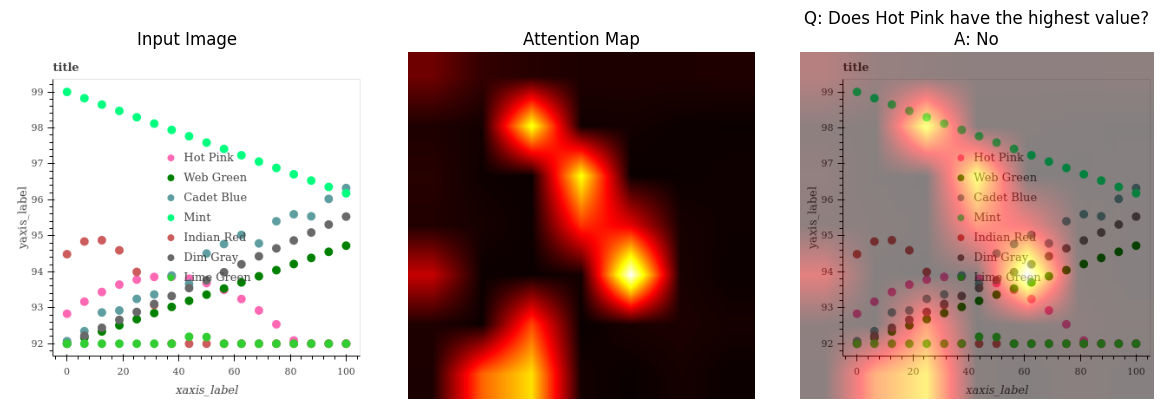


Question: Is Dark Turquoise greater than Orange?
True Answer: Yes


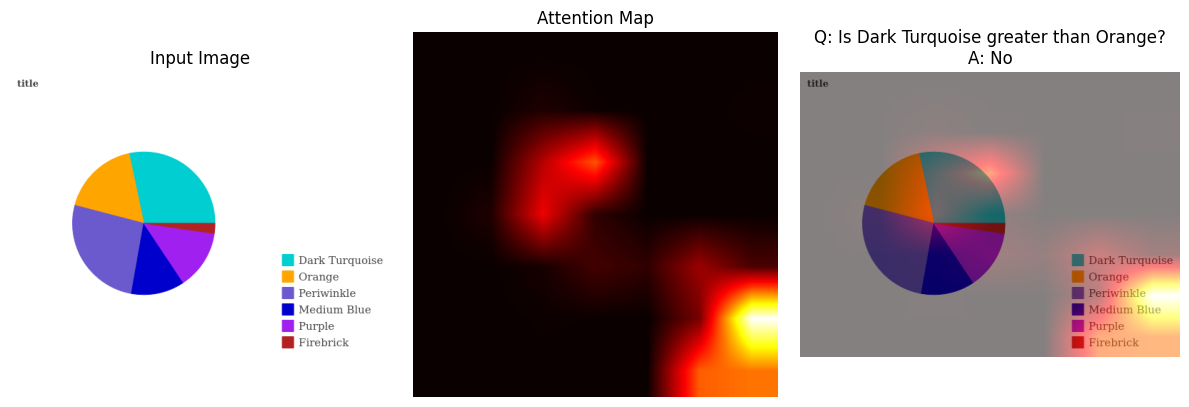


Question: Is Tomato less than Khaki?
True Answer: No


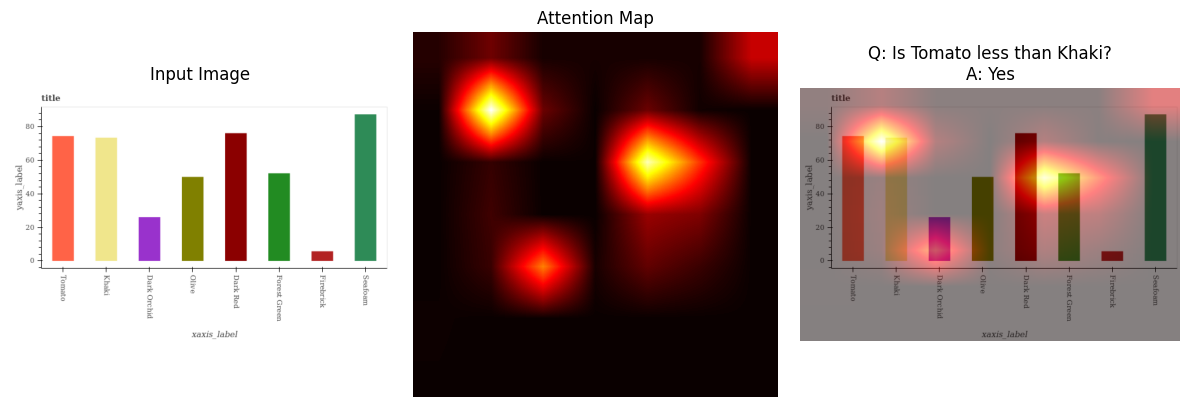


Question: Is Dodger Blue the minimum?
True Answer: No


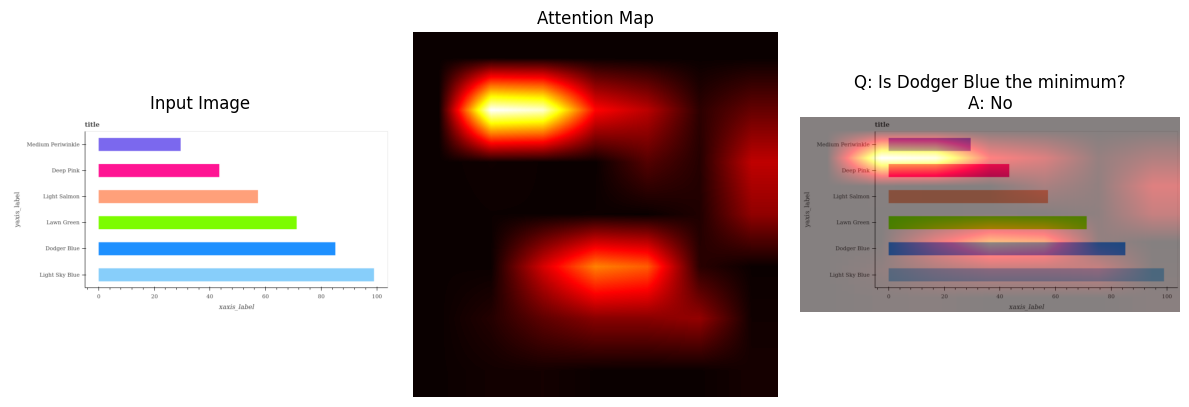


Question: Is Light Gold the minimum?
True Answer: No


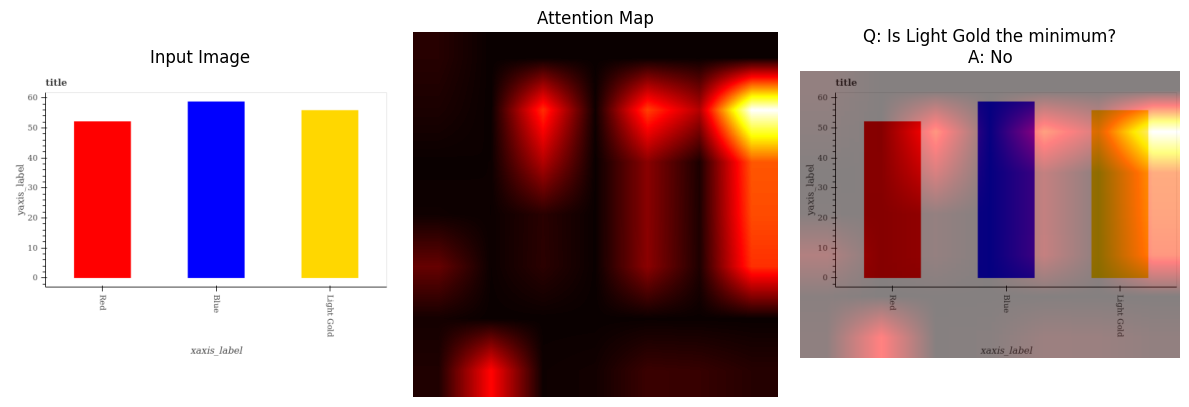

In [ ]:
show_predictions(model, splits['test'], vocab, val_transform, n=5)

### Attention Heatmap Analysis

The cross-attention heatmaps show which 7x7 spatial regions the model focuses on when answering each question. Key observations:

1. **Diffuse attention patterns** — The heatmaps spread across the entire image rather than sharply focusing on specific chart elements. This is expected for a from-scratch CNN — the CNN features aren't strong enough to give the attention mechanism anything specific to focus on.
2. **Partial spatial awareness** — On bar and line charts, attention tends to be slightly stronger in the chart area (center) than the margins or legend, suggesting the model has learned *where* charts live even if it cannot reliably distinguish *what* the chart shows.
3. **No clear correct/incorrect pattern** — There is no visible difference in attention maps between correct and incorrect predictions. This points to the CNN features being the weak link, not the attention mechanism.